<a href="https://colab.research.google.com/github/pinkprincess536/eeg/blob/main/eeg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mne numpy pandas matplotlib

In [ ]:
import mne
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/EEG_PROJECT"

os.makedirs(BASE_DIR, exist_ok=True)

print("Created:", BASE_DIR)

Created: /content/drive/MyDrive/EEG_PROJECT


In [ ]:
!pip install -q mne

import os
import subprocess

BASE_DIR = "/content/drive/MyDrive/EEG_PROJECT"

patients = {
    "chb01": [
        # Seizure
        "chb01_15.edf",
        "chb01_15.edf.seizures",
        "chb01_16.edf",
        "chb01_16.edf.seizures",
        "chb01_18.edf",
        "chb01_18.edf.seizures",
        "chb01_21.edf",
        "chb01_21.edf.seizures",

        # Non-seizure
        "chb01_17.edf",
        "chb01_19.edf",
        "chb01_20.edf"
    ],

    "chb02": [
        # Seizure
        "chb02_16.edf",
        "chb02_16.edf.seizures",
        "chb02_16+.edf",
        "chb02_16+.edf.seizures",
        "chb02_19.edf",
        "chb02_19.edf.seizures",

        # Non-seizure
        "chb02_10.edf",
        "chb02_11.edf",
        "chb02_12.edf",
        "chb02_13.edf"
    ],

    "chb03": [
        # Seizure
        "chb03_01.edf",
        "chb03_01.edf.seizures",
        "chb03_02.edf",
        "chb03_02.edf.seizures",
        "chb03_03.edf",
        "chb03_03.edf.seizures",
        "chb03_04.edf",
        "chb03_04.edf.seizures",

        # Non-seizure
        "chb03_05.edf",
        "chb03_06.edf",
        "chb03_07.edf"
    ]
}

for patient, files in patients.items():

    patient_dir = os.path.join(BASE_DIR, patient)
    os.makedirs(patient_dir, exist_ok=True)

    base_url = f"https://physionet.org/files/chbmit/1.0.0/{patient}/"

    print(f"\nDownloading {patient}...")

    for file in files:

        output_path = os.path.join(patient_dir, file)

        # Skip already-downloaded files
        if os.path.exists(output_path):
            print(f"Skipping {file} (already exists)")
            continue

        url = base_url + file

        print(f"Downloading {file}...")

        subprocess.run([
            "wget",
            "-q",
            "-O",
            output_path,
            url
        ])

print("\nAll downloads completed.")


Skipping chb01_15.edf (already exists)
Skipping chb01_15.edf.seizures (already exists)
Skipping chb01_16.edf (already exists)
Skipping chb01_16.edf.seizures (already exists)
Skipping chb01_18.edf (already exists)
Skipping chb01_18.edf.seizures (already exists)
Skipping chb01_21.edf (already exists)
Skipping chb01_21.edf.seizures (already exists)
Skipping chb01_17.edf (already exists)
Skipping chb01_19.edf (already exists)
Skipping chb01_20.edf (already exists)

Skipping chb02_16.edf (already exists)
Skipping chb02_16.edf.seizures (already exists)
Skipping chb02_16+.edf (already exists)
Skipping chb02_16+.edf.seizures (already exists)
Skipping chb02_19.edf (already exists)
Skipping chb02_19.edf.seizures (already exists)
Skipping chb02_10.edf (already exists)
Skipping chb02_11.edf (already exists)
Skipping chb02_12.edf (already exists)
Skipping chb02_13.edf (already exists)

Skipping chb03_01.edf (already exists)
Skipping chb03_01.edf.seizures (already exists)
Skipping chb03_02.edf (alr

In [ ]:
!ls "/content/drive/MyDrive/EEG_PROJECT"

chb01		     chb01-summary.txt.6  chb03
chb01-summary.txt    chb01-summary.txt.7  chb03-summary.txt
chb01-summary.txt.1  chb02		  chb03-summary.txt.1
chb01-summary.txt.2  chb02-summary.txt	  chb03-summary.txt.2
chb01-summary.txt.3  chb02-summary.txt.1  chb03-summary.txt.3
chb01-summary.txt.4  chb02-summary.txt.2
chb01-summary.txt.5  chb02-summary.txt.3


In [ ]:
!find "/content/drive/MyDrive/EEG_PROJECT" -type f | wc -l


48


In [ ]:
!ls "/content/drive/MyDrive/EEG_PROJECT/chb01"


chb01_15.edf	       chb01_17.edf	      chb01_20.edf
chb01_15.edf.seizures  chb01_18.edf	      chb01_21.edf
chb01_16.edf	       chb01_18.edf.seizures  chb01_21.edf.seizures
chb01_16.edf.seizures  chb01_19.edf


In [ ]:
import mne
import matplotlib.pyplot as plt

In [ ]:
seizure_file = "/content/drive/MyDrive/EEG_PROJECT/chb01/chb01_15.edf.seizures"

with open(seizure_file, "rb") as f:
    content = f.read()

print(content[:500])

b'\x00X\x17\xfc## time resolution: 256\x00\x00\xec\xff\xff\xff\xff\x01\x00\x00\xec\x06\x00\x00\xc4\x00\x80\x00\xec\x00\x00\x00(\x00\x84\x00\x00'


In [ ]:
import mne

file_path = "/content/drive/MyDrive/EEG_PROJECT/chb01/chb01_15.edf"

raw = mne.io.read_raw_edf(file_path, preload=False)

print(raw.info
      )

Extracting EDF parameters from /content/drive/MyDrive/EEG_PROJECT/chb01/chb01_15.edf...
Setting channel info structure...
Creating raw.info structure...
<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-07 01:44:44 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>


/tmp/ipykernel_6655/1749232387.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=False)


Using matplotlib as 2D backend.


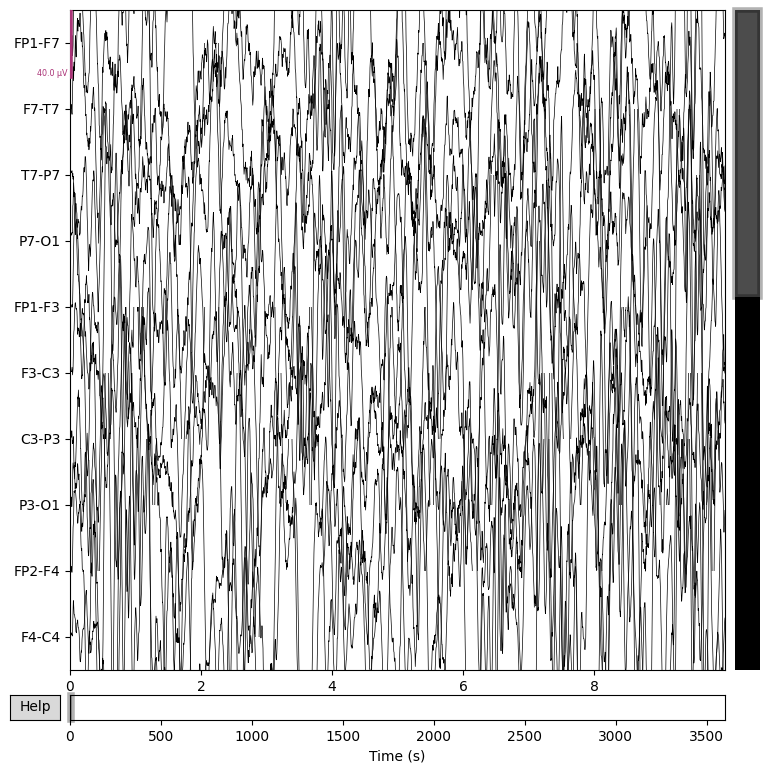

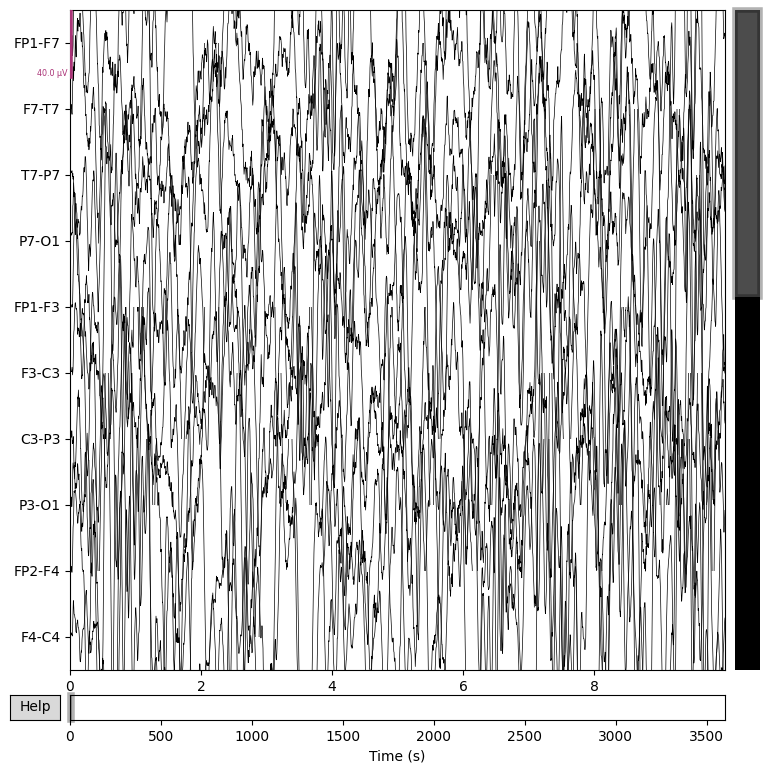

In [ ]:
raw.plot(duration=10, n_channels=10)

In [ ]:
duration_sec = raw.times[-1]

print("Seconds:", duration_sec)
print("Minutes:", duration_sec / 60)


Seconds: 3599.99609375
Minutes: 59.999934895833334


In [ ]:
!wget -P "/content/drive/MyDrive/EEG_PROJECT" \
https://physionet.org/files/chbmit/1.0.0/chb01/chb01-summary.txt

--2026-05-20 16:30:22--  https://physionet.org/files/chbmit/1.0.0/chb01/chb01-summary.txt
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5355 (5.2K) [text/plain]
Saving to: ‘/content/drive/MyDrive/EEG_PROJECT/chb01-summary.txt.8’

chb01-summary.txt.8 100%[===================>]   5.23K  --.-KB/s    in 0s      

2026-05-20 16:30:22 (611 MB/s) - ‘/content/drive/MyDrive/EEG_PROJECT/chb01-summary.txt.8’ saved [5355/5355]



In [ ]:
summary_path = "/content/drive/MyDrive/EEG_PROJECT/chb01-summary.txt"

with open(summary_path, "r") as f:
    content = f.read()

print(content[:5000])


Data Sampling Rate: 256 Hz
*************************

Channels in EDF Files:
**********************
Channel 1: FP1-F7
Channel 2: F7-T7
Channel 3: T7-P7
Channel 4: P7-O1
Channel 5: FP1-F3
Channel 6: F3-C3
Channel 7: C3-P3
Channel 8: P3-O1
Channel 9: FP2-F4
Channel 10: F4-C4
Channel 11: C4-P4
Channel 12: P4-O2
Channel 13: FP2-F8
Channel 14: F8-T8
Channel 15: T8-P8
Channel 16: P8-O2
Channel 17: FZ-CZ
Channel 18: CZ-PZ
Channel 19: P7-T7
Channel 20: T7-FT9
Channel 21: FT9-FT10
Channel 22: FT10-T8
Channel 23: T8-P8

File Name: chb01_01.edf
File Start Time: 11:42:54
File End Time: 12:42:54
Number of Seizures in File: 0

File Name: chb01_02.edf
File Start Time: 12:42:57
File End Time: 13:42:57
Number of Seizures in File: 0

File Name: chb01_03.edf
File Start Time: 13:43:04
File End Time: 14:43:04
Number of Seizures in File: 1
Seizure Start Time: 2996 seconds
Seizure End Time: 3036 seconds

File Name: chb01_04.edf
File Start Time: 14:43:12
File End Time: 15:43:12
Number of Seizures in File: 1
S

In [ ]:
!wget -P "/content/drive/MyDrive/EEG_PROJECT" \
https://physionet.org/files/chbmit/1.0.0/chb01/chb01-summary.txt

!wget -P "/content/drive/MyDrive/EEG_PROJECT" \
https://physionet.org/files/chbmit/1.0.0/chb02/chb02-summary.txt

!wget -P "/content/drive/MyDrive/EEG_PROJECT" \
https://physionet.org/files/chbmit/1.0.0/chb03/chb03-summary.txt

--2026-05-20 16:30:23--  https://physionet.org/files/chbmit/1.0.0/chb01/chb01-summary.txt
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5355 (5.2K) [text/plain]
Saving to: ‘/content/drive/MyDrive/EEG_PROJECT/chb01-summary.txt.9’

chb01-summary.txt.9 100%[===================>]   5.23K  --.-KB/s    in 0s      

2026-05-20 16:30:23 (720 MB/s) - ‘/content/drive/MyDrive/EEG_PROJECT/chb01-summary.txt.9’ saved [5355/5355]

--2026-05-20 16:30:23--  https://physionet.org/files/chbmit/1.0.0/chb02/chb02-summary.txt
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4471 (4.4K) [text/plain]
Saving to: ‘/content/drive/MyDrive/EEG_PROJECT/chb02-summary.txt.4’

chb02-summary.txt.4 100%[===================>]   4.37K  --.-KB/s    

In [ ]:
!ls "/content/drive/MyDrive/EEG_PROJECT"

chb01		     chb01-summary.txt.7  chb02-summary.txt.4
chb01-summary.txt    chb01-summary.txt.8  chb03
chb01-summary.txt.1  chb01-summary.txt.9  chb03-summary.txt
chb01-summary.txt.2  chb02		  chb03-summary.txt.1
chb01-summary.txt.3  chb02-summary.txt	  chb03-summary.txt.2
chb01-summary.txt.4  chb02-summary.txt.1  chb03-summary.txt.3
chb01-summary.txt.5  chb02-summary.txt.2  chb03-summary.txt.4
chb01-summary.txt.6  chb02-summary.txt.3


In [ ]:
import re

BASE_PATH = "/content/drive/MyDrive/EEG_PROJECT"

all_seizure_info = []

for patient, files in patients.items():

    summary_file = f"{BASE_PATH}/{patient}-summary.txt"

    with open(summary_file, "r") as f:
        content = f.read()

    for file_name in files:

        if file_name not in content:
            continue

        # Find section for this EDF
        pattern = rf"File Name: {re.escape(file_name)}(.*?)(?=File Name:|\Z)"

        match = re.search(pattern, content, re.S)

        if not match:
            continue

        section = match.group(1)

        seizure_starts = re.findall(
            r"Seizure Start Time:\s*(\d+)\s*seconds",
            section
        )

        seizure_ends = re.findall(
            r"Seizure End Time:\s*(\d+)\s*seconds",
            section
        )

        info = {
            "patient": patient,
            "file": file_name,
            "num_seizures": len(seizure_starts),
            "starts": seizure_starts,
            "ends": seizure_ends
        }

        all_seizure_info.append(info)

for item in all_seizure_info:
    print(item)

{'patient': 'chb01', 'file': 'chb01_15.edf', 'num_seizures': 1, 'starts': ['1732'], 'ends': ['1772']}
{'patient': 'chb01', 'file': 'chb01_16.edf', 'num_seizures': 1, 'starts': ['1015'], 'ends': ['1066']}
{'patient': 'chb01', 'file': 'chb01_18.edf', 'num_seizures': 1, 'starts': ['1720'], 'ends': ['1810']}
{'patient': 'chb01', 'file': 'chb01_21.edf', 'num_seizures': 1, 'starts': ['327'], 'ends': ['420']}
{'patient': 'chb01', 'file': 'chb01_17.edf', 'num_seizures': 0, 'starts': [], 'ends': []}
{'patient': 'chb01', 'file': 'chb01_19.edf', 'num_seizures': 0, 'starts': [], 'ends': []}
{'patient': 'chb01', 'file': 'chb01_20.edf', 'num_seizures': 0, 'starts': [], 'ends': []}
{'patient': 'chb02', 'file': 'chb02_16.edf', 'num_seizures': 1, 'starts': ['130'], 'ends': ['212']}
{'patient': 'chb02', 'file': 'chb02_16+.edf', 'num_seizures': 1, 'starts': ['2972'], 'ends': ['3053']}
{'patient': 'chb02', 'file': 'chb02_19.edf', 'num_seizures': 1, 'starts': ['3369'], 'ends': ['3378']}
{'patient': 'chb02'

In [ ]:
import mne

file_path = "/content/drive/MyDrive/EEG_PROJECT/chb01/chb01_15.edf"

raw = mne.io.read_raw_edf(file_path, preload=True)

print(raw)

Extracting EDF parameters from /content/drive/MyDrive/EEG_PROJECT/chb01/chb01_15.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_6655/3981689647.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True)


<RawEDF | chb01_15.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>


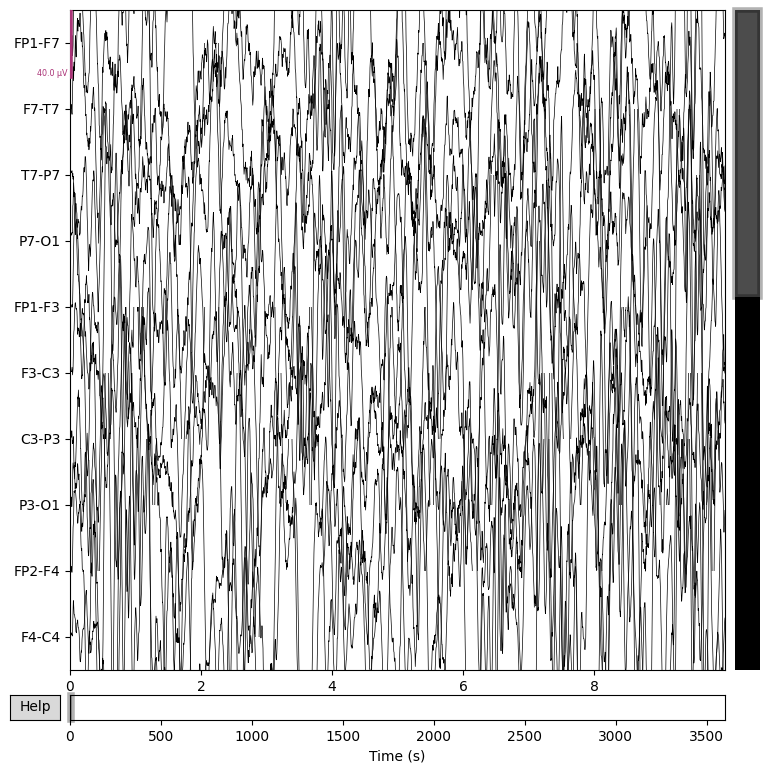

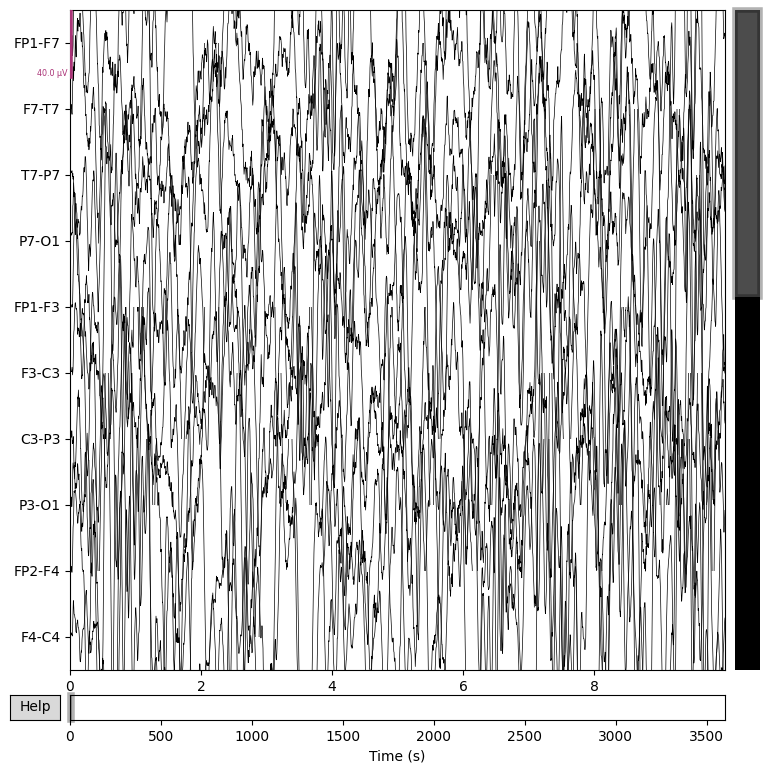

In [ ]:
raw.plot(duration=10, n_channels=10)

In [ ]:
!pip install mne

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = "/content/drive/MyDrive/EEG_PROJECT/chb01/chb01_15.edf"

raw = mne.io.read_raw_edf(file_path, preload=True)

print(raw)

Extracting EDF parameters from /content/drive/MyDrive/EEG_PROJECT/chb01/chb01_15.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_6655/2827085690.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True)


<RawEDF | chb01_15.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>


In [ ]:
raw.filter(0.5, 40)

# Remove 60 Hz electrical interference
raw.notch_filter(freqs=60)

print("\nFiltering Complete")

# =========================================================
# STEP 3 — CONVERT EEG OBJECT TO NUMPY ARRAY
# =========================================================

signal = raw.get_data()

print("\nSignal Shape:")
print(signal.shape)

# Shape meaning:
# (channels, time_samples)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband e

In [ ]:
import numpy as np
sfreq = raw.info['sfreq']

window_size_sec = 7

overlap = 0.5

# Convert seconds → samples
window_samples = int(window_size_sec * sfreq)

# Stride controls overlap movement
stride = int(window_samples * (1 - overlap))

print("\nWindow Parameters")
print("Sampling Frequency:", sfreq)
print("Window Samples:", window_samples)
print("Stride:", stride)

# =========================================================
# STEP 5 — GENERATE WINDOWS
# =========================================================

windows = []

total_samples = signal.shape[1]

for start in range(0, total_samples - window_samples, stride):

    end = start + window_samples

    # Extract window
    window = signal[:, start:end]

    windows.append(window)

windows = np.array(windows)

print("\nGenerated Windows Shape:")
print(windows.shape)

# Shape:
# (num_windows, channels, samples)

# =========================================================
# STEP 6 — LABEL WINDOWS
# =========================================================

# Seizure timestamps for chb01_15.edf
seizure_start = 1732
seizure_end = 1772

labels = []

for start in range(0, total_samples - window_samples, stride):

    # Convert sample index → seconds
    start_sec = start / sfreq
    end_sec = (start + window_samples) / sfreq

    # Check overlap with seizure interval
    if end_sec >= seizure_start and start_sec <= seizure_end:
        labels.append(1)
    else:
        labels.append(0)

labels = np.array(labels)

print("\nLabels Shape:")
print(labels.shape)

print("Total Seizure Windows:", np.sum(labels))
print("Total Non-Seizure Windows:", len(labels) - np.sum(labels))

# =========================================================
# FINAL DATASET
# =========================================================

X = windows
y = labels

print("\nFINAL DATASET")
print("X shape:", X.shape)
print("y shape:", y.shape)



Window Parameters
Sampling Frequency: 256.0
Window Samples: 1792
Stride: 896

Generated Windows Shape:
(1027, 23, 1792)

Labels Shape:
(1027,)
Total Seizure Windows: 14
Total Non-Seizure Windows: 1013

FINAL DATASET
X shape: (1027, 23, 1792)
y shape: (1027,)


In [ ]:
unique, counts = np.unique(y, return_counts=True)

print(dict(zip(unique, counts)))


{np.int64(0): np.int64(1013), np.int64(1): np.int64(14)}


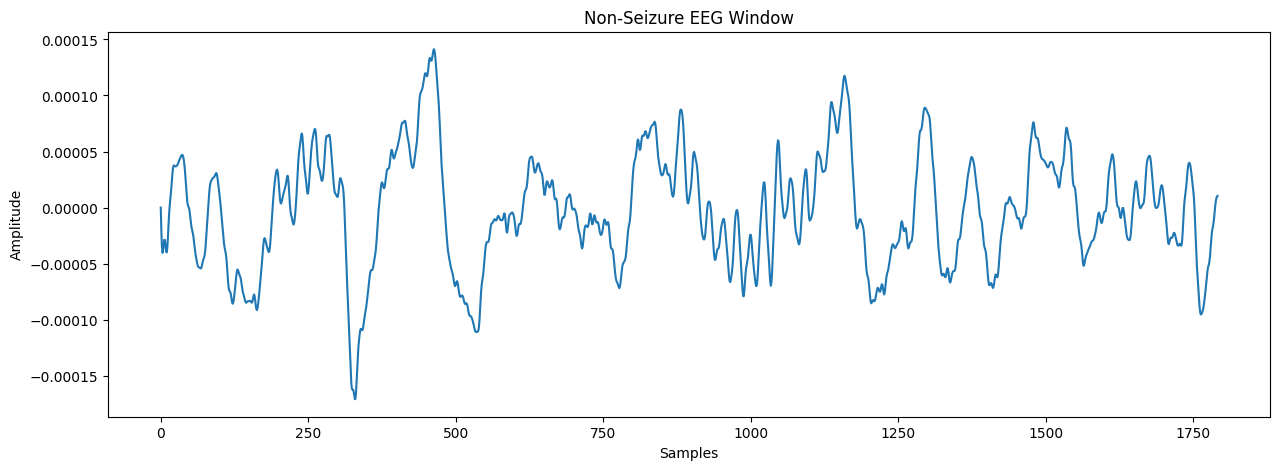

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(X[0][0])

plt.title("Non-Seizure EEG Window")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

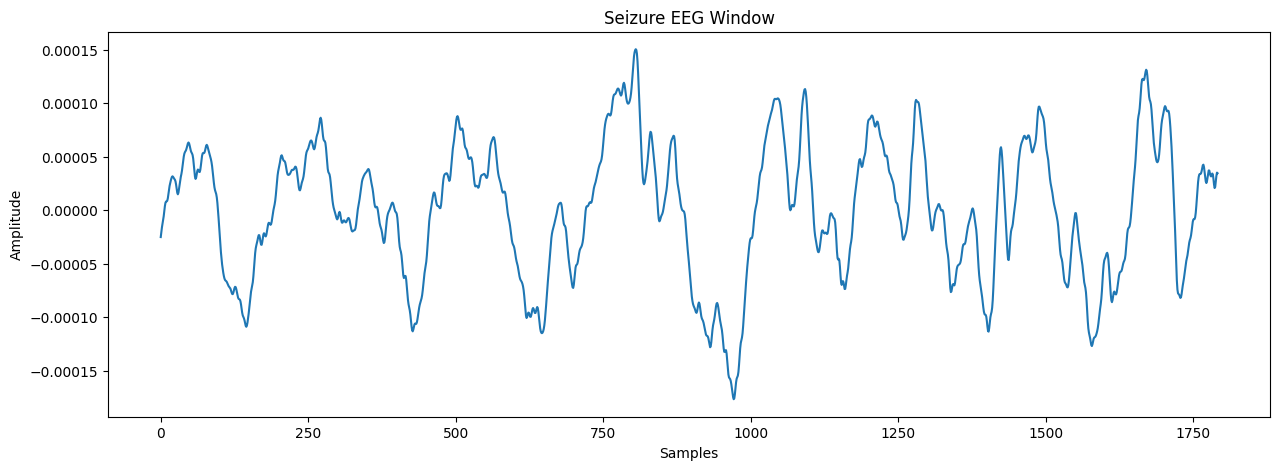

In [ ]:
seizure_idx = np.where(y == 1)[0][0]

plt.figure(figsize=(15,5))
plt.plot(X[seizure_idx][0])

plt.title("Seizure EEG Window")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [ ]:
from scipy.signal import butter, filtfilt

def bandpass_filter(data, lowcut=0.5, highcut=40, fs=256, order=5):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')

    filtered_data = filtfilt(b, a, data)

    return filtered_data

In [ ]:
signal = X[0][0]

filtered_signal = bandpass_filter(signal)

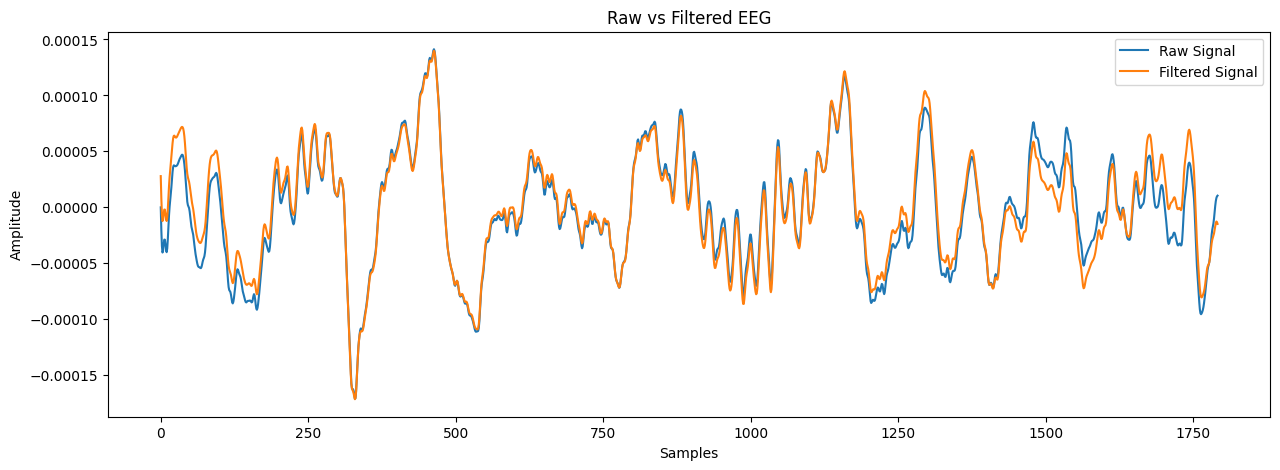

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(signal, label="Raw Signal")
plt.plot(filtered_signal, label="Filtered Signal")

plt.title("Raw vs Filtered EEG")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.legend()

plt.show()

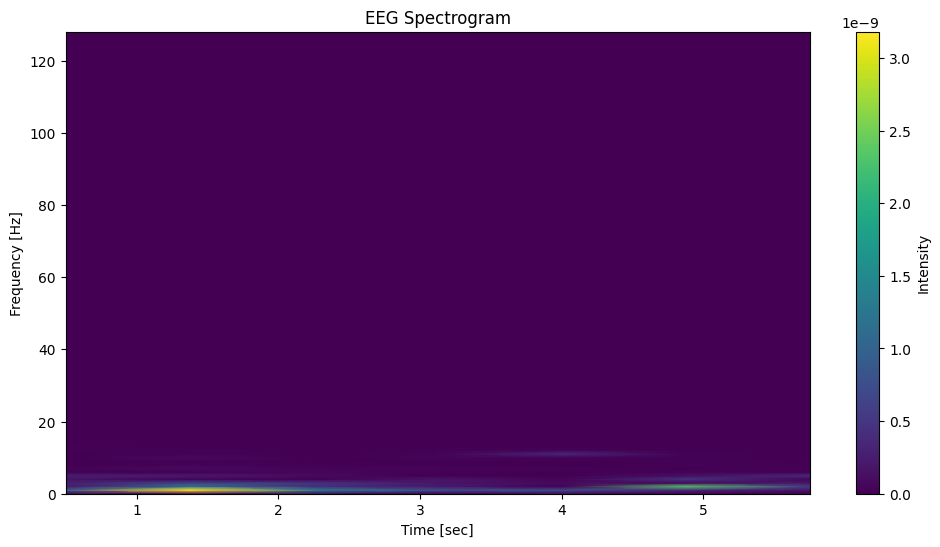

In [ ]:
from scipy.signal import spectrogram
import matplotlib.pyplot as plt

# Take one filtered EEG signal
signal = filtered_signal

# Generate spectrogram
frequencies, times, Sxx = spectrogram(
    signal,
    fs=256
)

# Plot spectrogram
plt.figure(figsize=(12,6))

plt.pcolormesh(
    times,
    frequencies,
    Sxx,
    shading='gouraud'
)

plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [sec]")
plt.title("EEG Spectrogram")

plt.colorbar(label="Intensity")

plt.show()

In [ ]:
import numpy as np

# First non-seizure window
non_seizure_idx = np.where(y == 0)[0][0]

# First seizure window
seizure_idx = np.where(y == 1)[0][0]

print("Non-seizure index:", non_seizure_idx)
print("Seizure index:", seizure_idx)

Non-seizure index: 0
Seizure index: 493


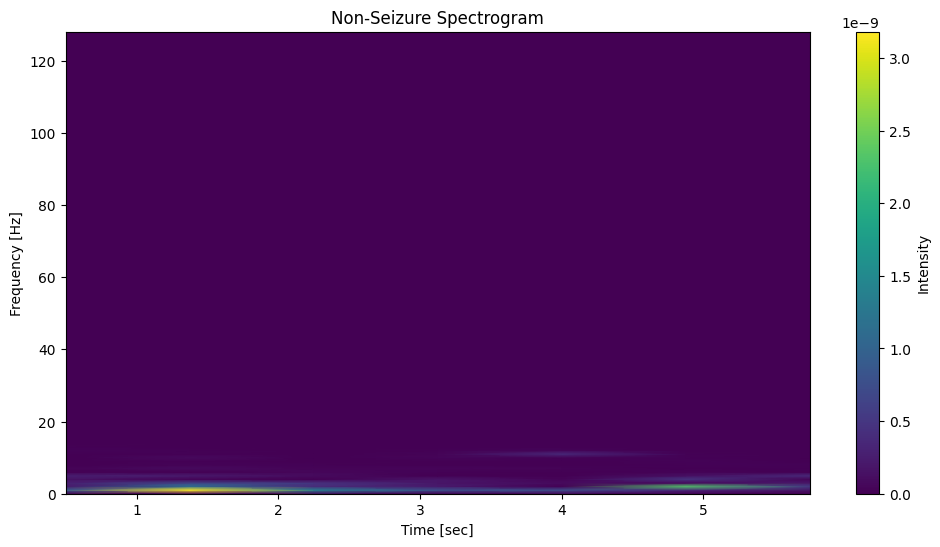

In [ ]:
from scipy.signal import spectrogram

non_seizure_signal = X[non_seizure_idx][0]

seizure_signal = X[seizure_idx][0]


filtered_non_seizure = bandpass_filter(non_seizure_signal)

filtered_seizure = bandpass_filter(seizure_signal)
frequencies, times, Sxx = spectrogram(
    filtered_non_seizure,
    fs=256
)

plt.figure(figsize=(12,6))

plt.pcolormesh(
    times,
    frequencies,
    Sxx,
    shading='gouraud'
)

plt.title("Non-Seizure Spectrogram")

plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [sec]")

plt.colorbar(label="Intensity")

plt.show()

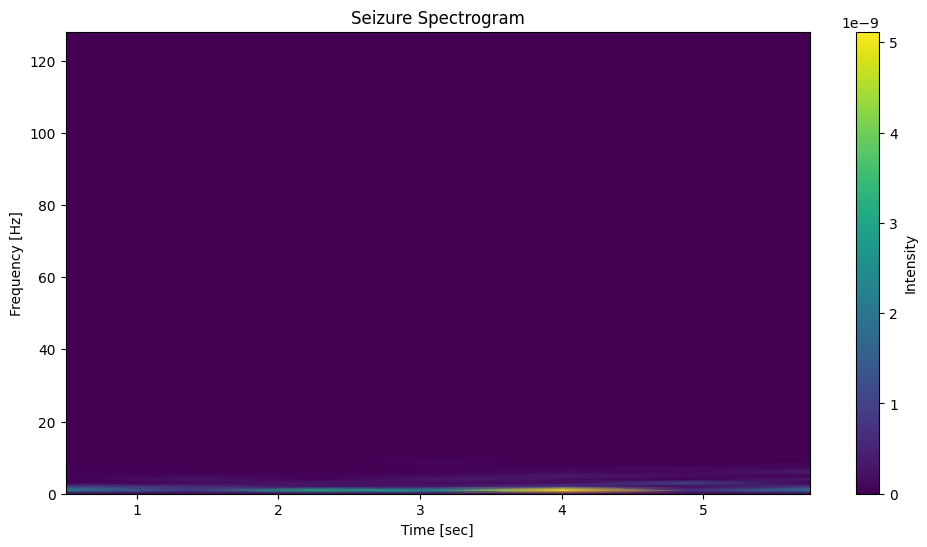

In [ ]:
frequencies, times, Sxx = spectrogram(
    filtered_seizure,
    fs=256
)

plt.figure(figsize=(12,6))

plt.pcolormesh(
    times,
    frequencies,
    Sxx,
    shading='gouraud'
)

plt.title("Seizure Spectrogram")

plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [sec]")

plt.colorbar(label="Intensity")

plt.show()

In [ ]:
from scipy.signal import spectrogram
import numpy as np

spectrogram_dataset = []

for window in X:

    # Use first EEG channel
    signal = window[0]

    # Apply bandpass filter
    filtered_signal = bandpass_filter(signal)

    # Generate spectrogram
    frequencies, times, Sxx = spectrogram(
        filtered_signal,
        fs=256
    )

    # Store spectrogram
    spectrogram_dataset.append(Sxx)

# Convert to NumPy array
spectrogram_dataset = np.array(spectrogram_dataset)

print("Spectrogram Dataset Shape:")
print(spectrogram_dataset.shape)

Spectrogram Dataset Shape:
(1027, 129, 7)


In [ ]:
import numpy as np

print(np.unique(y, return_counts=True))

(array([0, 1]), array([1013,   14]))


In [ ]:
import numpy as np

# Get indices
seizure_indices = np.where(y == 1)[0]
non_seizure_indices = np.where(y == 0)[0]

# Randomly choose non-seizure samples
selected_non_seizure = np.random.choice(
    non_seizure_indices,
    size=100,
    replace=False
)

# Combine indices
balanced_indices = np.concatenate([
    seizure_indices,
    selected_non_seizure
])

# Shuffle
np.random.shuffle(balanced_indices)

# Create balanced dataset
X_balanced = spectrogram_dataset[balanced_indices]
y_balanced = y[balanced_indices]

print("Balanced Dataset Shape:")
print(X_balanced.shape)

print(np.unique(y_balanced, return_counts=True))

Balanced Dataset Shape:
(114, 129, 7)
(array([0, 1]), array([100,  14]))


In [ ]:
X_balanced = X_balanced.astype(np.float32)

X_balanced = (
    X_balanced - X_balanced.mean()
) / X_balanced.std()

print(X_balanced.shape)


(114, 129, 7)


In [ ]:
X_balanced = np.expand_dims(X_balanced, axis=1)

print(X_balanced.shape)

(114, 1, 129, 7)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

print(X_train.shape)
print(X_test.shape)

(91, 1, 129, 7)
(23, 1, 129, 7)


In [ ]:
import torch

# Convert spectrograms
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# Convert labels
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([91, 1, 129, 7])
torch.Size([91])


In [ ]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

print("Train Dataset Size:", len(train_dataset))
print("Test Dataset Size:", len(test_dataset))

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

print("DataLoaders Created")

Train Dataset Size: 91
Test Dataset Size: 23
DataLoaders Created


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class EEGCNN(nn.Module):

    def __init__(self):
        super(EEGCNN, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(16 * 64 * 3, 32)

        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):

        x = self.pool(
            F.relu(self.conv1(x))
        )

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))

        x = self.fc2(x)

        return x

In [ ]:
model = EEGCNN()

print(model)

EEGCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3072, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=2, bias=True)
)


In [ ]:
import torch.optim as optim
import torch.nn as nn

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for inputs, labels in train_loader:

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch 1/10, Loss: 0.3590
Epoch 2/10, Loss: 0.1899
Epoch 3/10, Loss: 0.0813
Epoch 4/10, Loss: 0.0620
Epoch 5/10, Loss: 0.0637
Epoch 6/10, Loss: 0.0444
Epoch 7/10, Loss: 0.0365
Epoch 8/10, Loss: 0.0326
Epoch 9/10, Loss: 0.0339
Epoch 10/10, Loss: 0.0232


In [ ]:
model.eval()

EEGCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3072, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=2, bias=True)
)

In [ ]:
correct = 0
total = 0

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 100.00%


In [ ]:
import numpy as np

def create_windows(signal, sfreq,
                   window_size_sec=7,
                   overlap=0.5):

    window_samples = int(window_size_sec * sfreq)

    stride = int(window_samples * (1 - overlap))

    windows = []

    total_samples = signal.shape[1]

    for start in range(
        0,
        total_samples - window_samples,
        stride
    ):

        end = start + window_samples

        window = signal[:, start:end]

        windows.append(window)

    return np.array(windows)